In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
germline_col = ["FID1", "IID1", "FID2", "IID2", "CHR", "SEG_START_BP", "SEG_END_BP", 
                "SEG_START_SNP", "SEG_END_SNP", "SNP", "LENGTH", "UNIT", "MISMATCH",
               "HOMOZYGOUS1", "HOMOZYGOUS2"]

In [22]:
def read_germline(population):
    df = pd.read_csv(f"germline/chr10_{population}_germline.match", delim_whitespace=True, header=None)
    df.columns = germline_col
    df_ibd = df.groupby(["IID1", "IID2"]).agg({"LENGTH": "sum", "UNIT": "first"}).reset_index()
    return df_ibd

def plink_plot(df):
    fig = plt.figure()
    plt.scatter(df["Z0"], df["Z1"])
    plt.xlabel("P(IBD=0)", size=15)
    plt.ylabel("P(IBD=1)", size=15)
    plt.show()

def plot_comparison(df, yax = "PI_HAT"):
    fig = plt.figure()
    plt.scatter(df["LENGTH"], df["PI_HAT"])
    plt.xlabel("GERMLINE length", size=15)
    plt.ylabel(f"PLINK {yax.lower()}", size=15)
    plt.show()
    
def compare_plink_germline(df_plink, df_germline, plot = True, yax = "PI_HAT"):
    df_full = (
        df_plink
        .merge(df_germline, how = "left", on = ["IID1", "IID2"])
        .fillna({"LENGTH": 0, "UNIT": "MB"})
    )
    
    if plot:
        plot_comparison(df_full, yax)
        
    return df_full

In [17]:
plink_lwk = pd.read_csv("plink/chr10_LWK_plink.genome", 
                 delim_whitespace=True)
plink_fin = pd.read_csv("plink/chr10_FIN_plink.genome", 
                 delim_whitespace=True)
plink_chs = pd.read_csv("plink/chr10_CHS_plink.genome", 
                 delim_whitespace=True)

In [18]:
germline_lwk = read_germline("LWK")
germline_fin = read_germline("FIN")
germline_chs = read_germline("CHS")

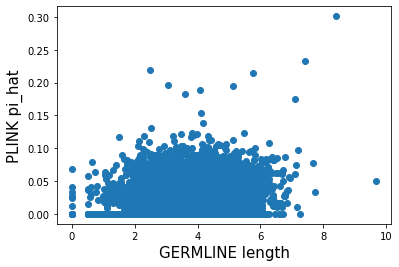

In [23]:
full_lwk = compare_plink_germline(plink_lwk, germline_lwk)

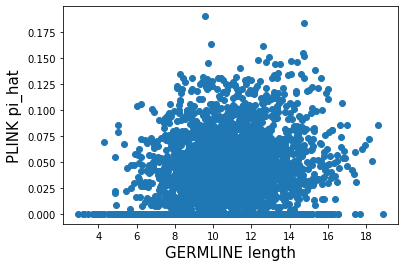

In [24]:
full_fin = compare_plink_germline(plink_fin, germline_fin)

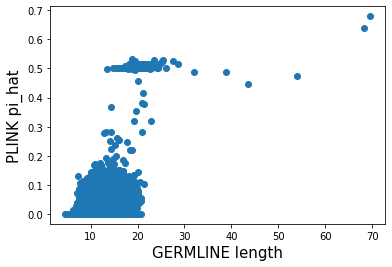

In [26]:
full_chs = compare_plink_germline(plink_chs, germline_chs)

In [30]:
df_genome = pd.read_csv("igsr-1000 genomes 30x on grch38-samples.tsv", sep='\t')
pedigree = pd.read_csv("pedigree.txt", sep=" ")
df_genome.columns = ["sampleID", "sex", "biosampleID", "pop", "pop_name", "subpop", "subpop_name", "popID", "collection"]

In [33]:
df = df_genome.merge(pedigree, how = "left", on = "sampleID")

In [37]:
df.to_csv("full_data.csv", index = False)